# Week 3 — CNN Model Training and Evaluation

In Week 3, I focused on building and training a Convolutional Neural Network (CNN) model for American Sign Language alphabet recognition.

The main goal of this week was to train a deep learning model that can classify hand gesture images into 29 classes.

The model was trained using preprocessed ASL images and evaluated using accuracy, loss graphs, and a confusion matrix.

#Install Kaggle

In [1]:
!pip install kaggle -q

#Upload Kaggle API Key

In [2]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"darynminal","key":"6b38091e2cb8901c5eb56442ea926569"}'}

#Setup Kaggle

In [3]:
import os
import shutil

os.makedirs("/root/.kaggle", exist_ok=True)

shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")

os.chmod("/root/.kaggle/kaggle.json", 600)

print("Kaggle API key is ready.")

Kaggle API key is ready.


#Download Dataset

In [4]:
!kaggle datasets download -d grassknoted/asl-alphabet

Dataset URL: https://www.kaggle.com/datasets/grassknoted/asl-alphabet
License(s): GPL-2.0
100% 1.03G/1.03G [00:07<00:00, 143MB/s]



#Extract Dataset

In [5]:
import zipfile

zip_path = "/content/asl-alphabet.zip"
extract_path = "/content/asl_alphabet"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully.")

Dataset extracted successfully.


#Check Dataset Folder

In [6]:
import os

print(os.listdir("/content/asl_alphabet"))

['asl_alphabet_test', 'asl_alphabet_train']


#Set Train Directory

In [7]:
train_dir = "/content/asl_alphabet/asl_alphabet_train/asl_alphabet_train"

print("Train path exists:", os.path.exists(train_dir))
print("Classes:", os.listdir(train_dir)[:10])

Train path exists: True
Classes: ['del', 'C', 'T', 'E', 'P', 'N', 'U', 'Y', 'I', 'A']


#Import Libraries

In [8]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

#Basic Settings

In [9]:
img_size = 64
batch_size = 32
num_classes = 29

#Data Preprocessing and Augmentation

In [10]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8, 1.2]
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

Found 69600 images belonging to 29 classes.
Found 17400 images belonging to 29 classes.


I used ImageDataGenerator for preprocessing and augmentation.

Images are normalized by dividing pixel values by 255. This helps the CNN model train better.

I also used augmentation techniques such as rotation, zoom, shifting, and brightness adjustment. These techniques make the model more flexible because real-life hand gesture images may have different angles, positions, and lighting.

#Show Class Names

In [11]:
class_names = list(train_generator.class_indices.keys())

print("Number of classes:", len(class_names))
print(class_names)

Number of classes: 29
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


#Visualize Sample Images

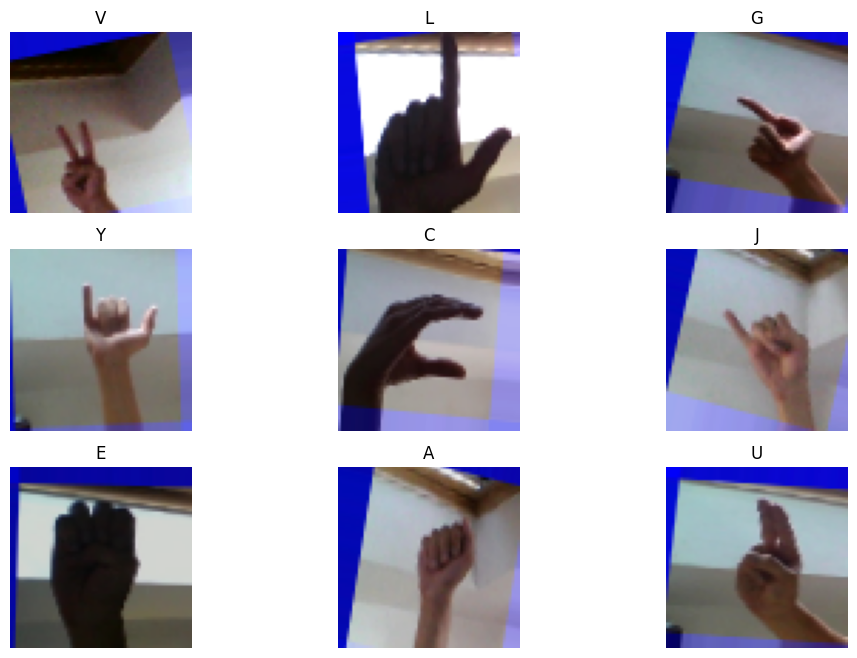

In [12]:
images, labels = next(train_generator)

plt.figure(figsize=(12, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    class_index = np.argmax(labels[i])
    plt.title(class_names[class_index])
    plt.axis("off")

plt.show()

#Build CNN Model

In [16]:
model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(img_size, img_size, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D(2, 2),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(num_classes, activation="softmax")
])

I used a Convolutional Neural Network because CNNs are suitable for image classification tasks.

The convolutional layers detect visual patterns from images, such as hand shape, finger position, edges, and gesture structure.

The pooling layers reduce image size and help the model focus on the most important features.

The final layer has 29 neurons because the dataset contains 29 classes. Softmax is used because the model must choose one class from many possible classes.

#Compile Model

In [17]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 29)             │         3,741 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 686,941 (2.62 MB)

 Trainable params: 686,941 (2.62 MB)

 Non-trainable params: 0 (0.00 B)

#Create Folders

In [18]:
os.makedirs("/content/models", exist_ok=True)
os.makedirs("/content/results", exist_ok=True)

#Train Model

In [ ]:
checkpoint = ModelCheckpoint(
    "/content/models/asl_cnn_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - accuracy: 0.2970 - loss: 2.3758
Epoch 1: val_accuracy improved from None to 0.66500, saving model to /content/models/asl_cnn_model.h5



Epoch 1: finished saving model to /content/models/asl_cnn_model.h5
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 794s 364ms/step - accuracy: 0.4860 - loss: 1.6653 - val_accuracy: 0.6650 - val_loss: 1.0938
Epoch 2/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 0.7520 - loss: 0.7388
Epoch 2: val_accuracy improved from 0.66500 to 0.75580, saving model to /content/models/asl_cnn_model.h5



Epoch 2: finished saving model to /content/models/asl_cnn_model.h5
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 724s 333ms/step - accuracy: 0.7815 - loss: 0.6452 - val_accuracy: 0.7558 - val_loss: 0.7948
Epoch 3/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 0.8517 - loss: 0.4350
Epoch 3: val_accuracy improved from 0.75580 to 0.80713, saving model to /content/models/asl_cnn_model.h5



Epoch 3: finished saving model to /content/models/asl_cnn_model.h5
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 709s 326ms/step - accuracy: 0.8629 - loss: 0.4030 - val_accuracy: 0.8071 - val_loss: 0.6631
Epoch 4/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 0.8939 - loss: 0.3094
Epoch 4: val_accuracy improved from 0.80713 to 0.80851, saving model to /content/models/asl_cnn_model.h5



Epoch 4: finished saving model to /content/models/asl_cnn_model.h5
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 709s 326ms/step - accuracy: 0.9024 - loss: 0.2900 - val_accuracy: 0.8085 - val_loss: 0.7071
Epoch 5/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 0.9201 - loss: 0.2452
Epoch 5: val_accuracy improved from 0.80851 to 0.82925, saving model to /content/models/asl_cnn_model.h5



Epoch 5: finished saving model to /content/models/asl_cnn_model.h5
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 716s 329ms/step - accuracy: 0.9239 - loss: 0.2320 - val_accuracy: 0.8293 - val_loss: 0.6423
Epoch 6/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - accuracy: 0.9356 - loss: 0.1970
Epoch 6: val_accuracy did not improve from 0.82925
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 712s 327ms/step - accuracy: 0.9389 - loss: 0.1874 - val_accuracy: 0.8232 - val_loss: 0.7367
Epoch 7/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - accuracy: 0.9459 - loss: 0.1690
Epoch 7: val_accuracy improved from 0.82925 to 0.85149, saving model to /content/models/asl_cnn_model.h5



Epoch 7: finished saving model to /content/models/asl_cnn_model.h5
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 713s 328ms/step - accuracy: 0.9491 - loss: 0.1599 - val_accuracy: 0.8515 - val_loss: 0.5987
Epoch 8/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 0.9540 - loss: 0.1403
Epoch 8: val_accuracy did not improve from 0.85149
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 709s 326ms/step - accuracy: 0.9543 - loss: 0.1406 - val_accuracy: 0.8379 - val_loss: 0.6984
Epoch 9/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - accuracy: 0.9590 - loss: 0.1263
Epoch 9: val_accuracy improved from 0.85149 to 0.85345, saving model to /content/models/asl_cnn_model.h5



Epoch 9: finished saving model to /content/models/asl_cnn_model.h5
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 710s 327ms/step - accuracy: 0.9594 - loss: 0.1274 - val_accuracy: 0.8534 - val_loss: 0.6401
Epoch 10/10
1890/2175 ━━━━━━━━━━━━━━━━━━━━ 1:24 296ms/step - accuracy: 0.9651 - loss: 0.1110

The model was trained for 10 epochs.

I used ModelCheckpoint to save the best version of the model according to validation accuracy.

I also used EarlyStopping to stop training if the validation loss does not improve. This helps reduce overfitting.

#Accuracy Graph

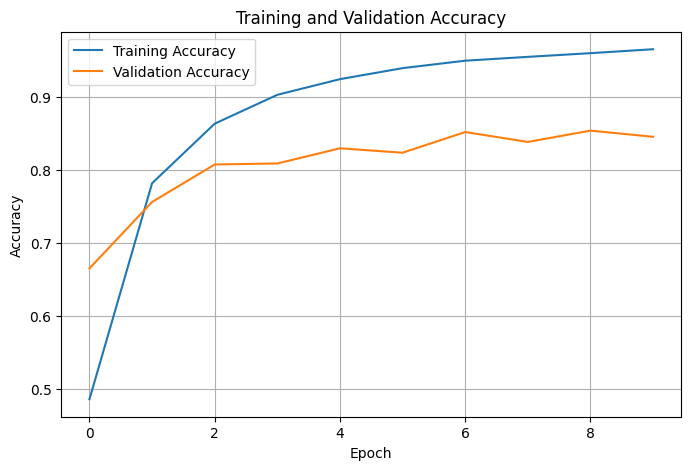

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.savefig("/content/results/accuracy_plot.png")
plt.show()

#Loss Graph

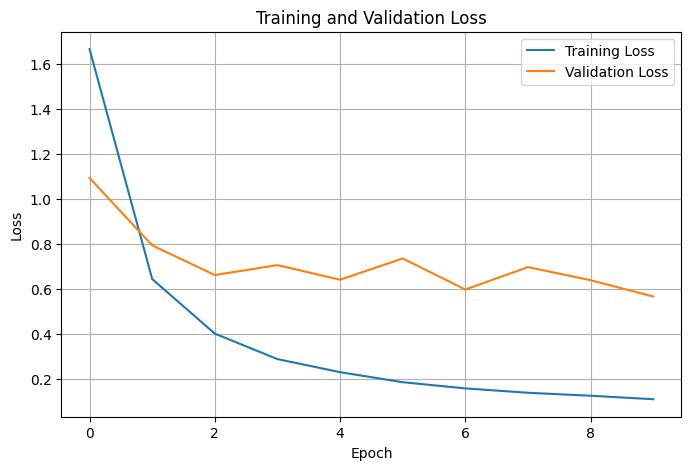

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.savefig("/content/results/loss_plot.png")
plt.show()

#Evaluate Model

In [22]:
val_loss, val_accuracy = model.evaluate(val_generator)

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)

544/544 ━━━━━━━━━━━━━━━━━━━━ 96s 174ms/step - accuracy: 0.8440 - loss: 0.5776
Validation Loss: 0.5775965452194214
Validation Accuracy: 0.8440229892730713


#Prediction

In [23]:
predictions = model.predict(val_generator)

y_pred = np.argmax(predictions, axis=1)
y_true = val_generator.classes

544/544 ━━━━━━━━━━━━━━━━━━━━ 79s 144ms/step


#Confusion Matrix

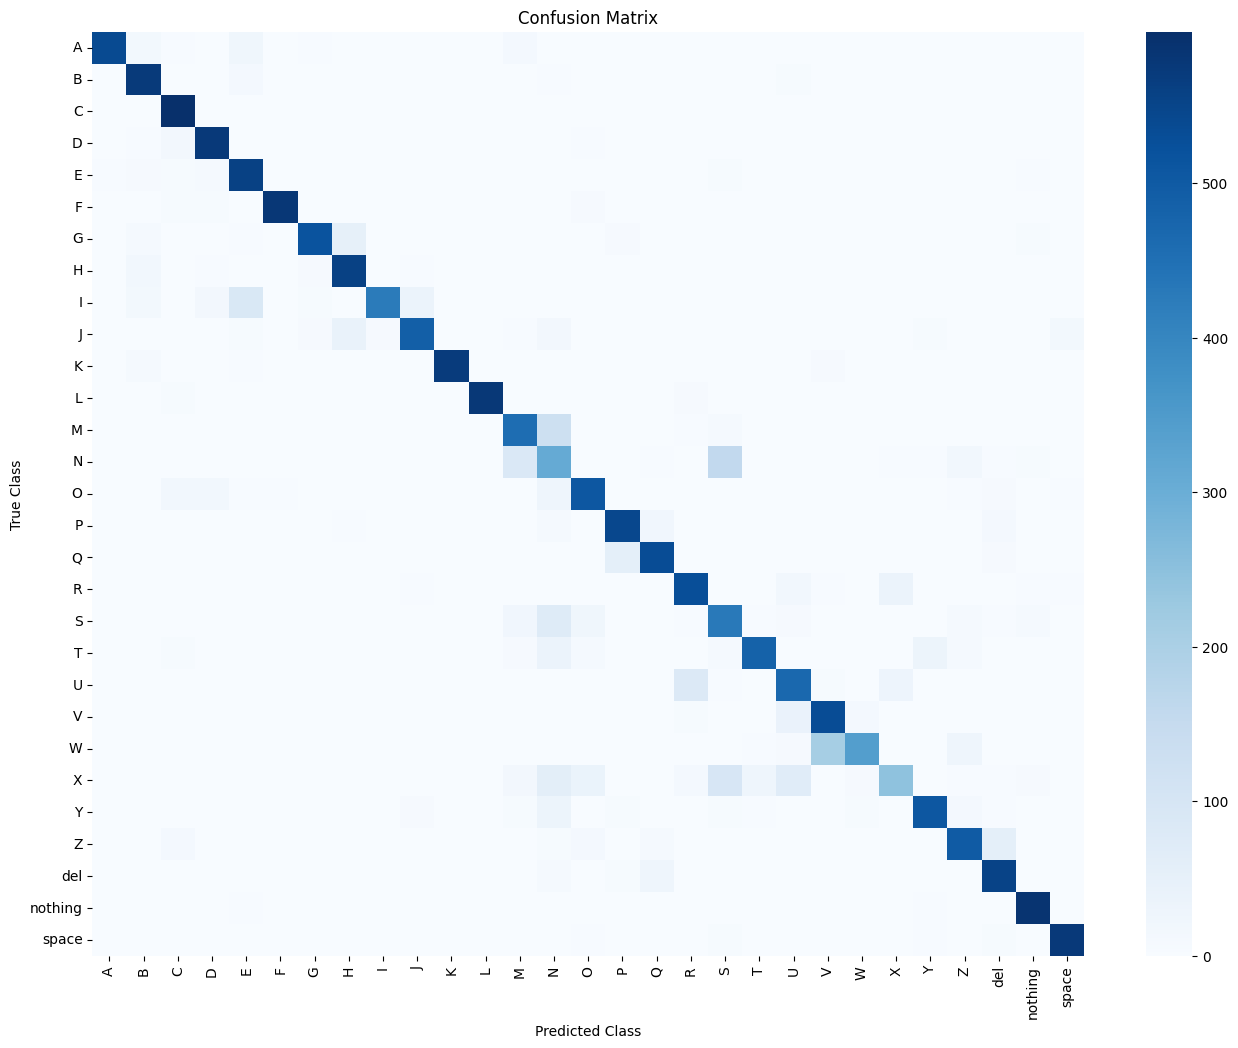

In [24]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(16, 12))
sns.heatmap(
    cm,
    annot=False,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.savefig("/content/results/confusion_matrix.png")
plt.show()

#Classification Report

In [25]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)

              precision    recall  f1-score   support

           A       0.99      0.90      0.94       600
           B       0.87      0.96      0.91       600
           C       0.89      1.00      0.94       600
           D       0.91      0.96      0.93       600
           E       0.79      0.93      0.86       600
           F       0.98      0.97      0.98       600
           G       0.95      0.86      0.90       600
           H       0.85      0.93      0.89       600
           I       0.98      0.71      0.82       600
           J       0.90      0.81      0.86       600
           K       1.00      0.95      0.97       600
           L       0.99      0.96      0.98       600
           M       0.74      0.76      0.75       600
           N       0.43      0.52      0.47       600
           O       0.82      0.84      0.83       600
           P       0.86      0.91      0.89       600
           Q       0.89      0.89      0.89       600
           R       0.81    

#Save Final Model

In [26]:
model.save("/content/models/asl_cnn_final_model.h5")

print("Final model saved successfully.")

Final model saved successfully.


#Download Results

In [27]:
from google.colab import files

files.download("/content/models/asl_cnn_model.h5")
files.download("/content/models/asl_cnn_final_model.h5")
files.download("/content/results/accuracy_plot.png")
files.download("/content/results/loss_plot.png")
files.download("/content/results/confusion_matrix.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Week 3 Conclusion

During Week 3, I trained a CNN model for ASL alphabet recognition.

First, I downloaded the ASL Alphabet dataset from Kaggle and extracted it in Google Colab. Then I prepared the images using resizing, normalization, and augmentation.

After that, I built a CNN model with convolutional layers, pooling layers, dense layers, and dropout. The model was trained to classify 29 ASL gesture classes.

I evaluated the model using validation accuracy, validation loss, accuracy/loss graphs, confusion matrix, and classification report.

The trained model was saved and will be used later in the Streamlit application.

Overall, Week 3 was focused on the main deep learning part of the project.